In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from episode_sampler import EpisodeSampler
from protonet import ProtoNet, ProtoNetEncoder
from utils import deterministic, train_protonet, select_fixed_subset

In [ ]:
with open("../Config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Train

In [ ]:
data = "Mnist"
experiment_parameters = config["experiment_1"]
lr = experiment_parameters["lr"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
epochs = experiment_parameters["epochs"]
episodes = experiment_parameters["episodes"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]

train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = ProtoNetEncoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = ProtoNet(encoder)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

mnist_vis_images, mnist_vis_labels = select_fixed_subset(
    val_images,
    val_labels,
    samples_per_class=100
)

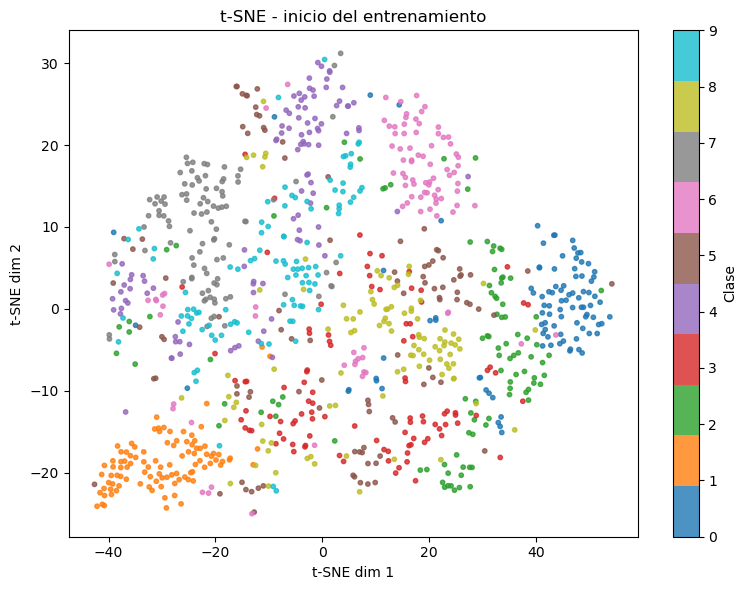

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

...

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

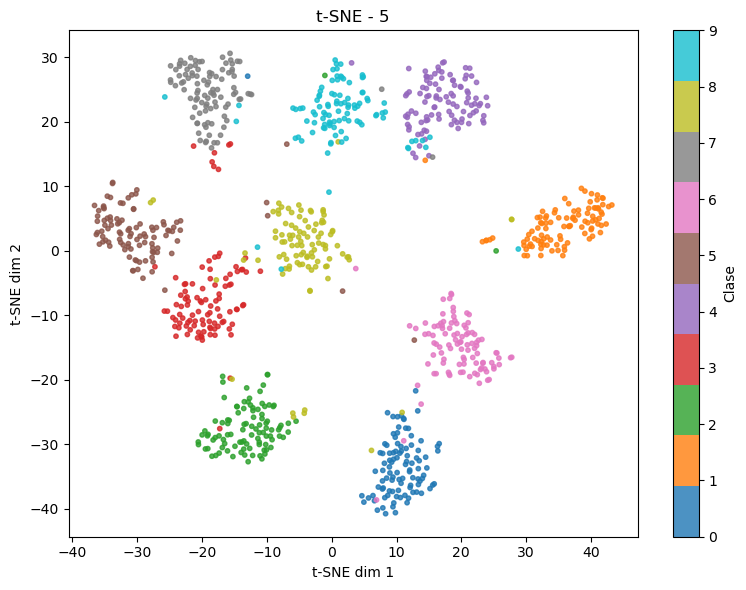

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

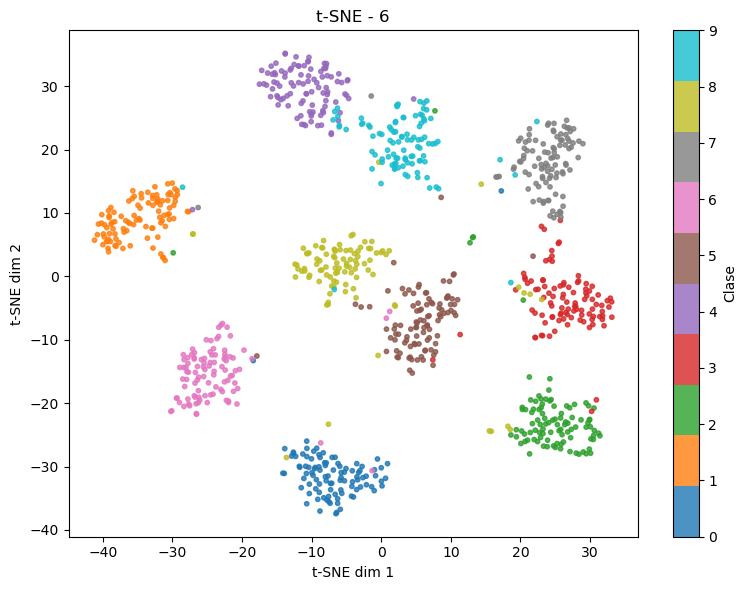

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
deterministic(config["xtra"]["seed"])
history = train_protonet(
    model=model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    episodes=episodes,
    tsne_images=mnist_vis_images,
    tsne_labels=mnist_vis_labels,
    tsne_dir="../images/tsne_protonet",
)

In [7]:
path = "../models/weights/protonet_mnist.pth"
model.save(path)

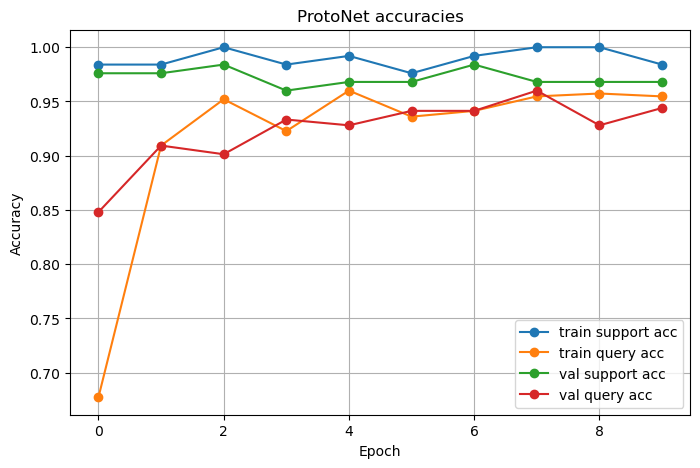

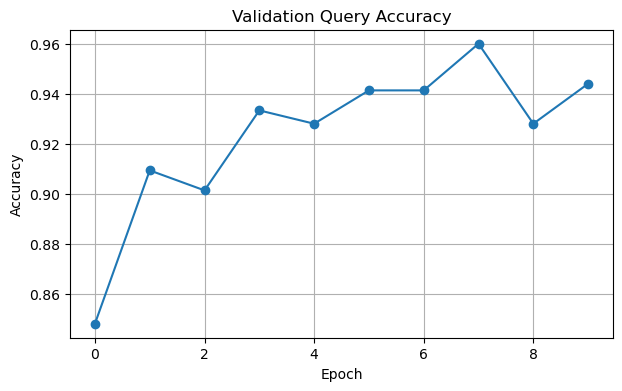

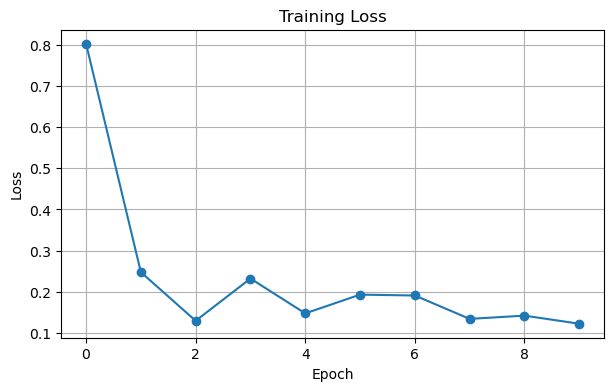

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_support_acc"], label="train support acc", marker="o")
plt.plot(history["train_query_acc"], label="train query acc", marker="o")
plt.plot(history["val_support_acc"], label="val support acc", marker="o")
plt.plot(history["val_query_acc"], label="val query acc", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ProtoNet accuracies")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_query_acc"], marker="o")
plt.title("Validation Query Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Eval

In [8]:
path = "../models/weights/protonet_mnist.pth"
encoder = ProtoNetEncoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
model = ProtoNet(encoder)
model.load(path, device)

In [ ]:
######HAY QUE TERMINAR ESTA CELDA!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

def eval_episode(model, sampler, device):
    model.eval()
    with torch.no_grad():
        images, labels = sampler.sample_episode()
        images, labels = images.to(device), labels.to(device)
        logits, _, _, _ = model(images, sampler.n_way, sampler.k_shot, sampler.q_query)
        query_labels = labels[sampler.n_way * sampler.k_shot:]
        pred_labels = torch.argmax(logits, dim=1)
        correct = (pred_labels == query_labels).sum().item()
    return correct

ks = [1, 2, 4, 8, 16]
q = 10
accuracies = {"Mnist-M": [], "Svhn": []}
data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Svhn"
test_svhn_images, test_svhn_labels = load_data("test", config[data]["dataset_output_dir"])

for k in ks:
    mnist_m_sampler = EpisodeSampler(images=test_mnist_m_images, labels=test_mnist_m_labels,
                                  n_way=n_way, k_shot=k, q_query=q)
    svhn_sampler = EpisodeSampler(images=test_svhn_images, labels=test_svhn_labels,
                                  n_way=n_way, k_shot=k, q_query=q)
    
    total_correct_mnist_m = 0
    total_correct_svhn = 0
    total_samples = 0
    
    for _ in range(100):  # Evaluar en 100 episodios
        correct = eval_episode(model, mnist_m_sampler, device)
        total_correct_mnist_m += correct
        correct = eval_episode(model, svhn_sampler, device)
        total_correct_svhn += correct
        total_samples += q  # Cada episodio tiene q muestras de consulta
    
    accuracy_mnist_m = total_correct_mnist_m / total_samples
    accuracy_svhn = total_correct_svhn / total_samples
    accuracies["Mnist-M"].append(accuracy_mnist_m)
    accuracies["Svhn"].append(accuracy_svhn)
    print(f"k={k}: Accuracy MNIST-M={accuracy_mnist_m:.4f}, Accuracy SVHN={accuracy_svhn:.4f}")